# 图片数据建模流程范例
- cifar2数据集为cifar10数据集的子集，只包括前两种类别airplane和automobile  
- 训练集有airplane和automobile图片各5000张，测试集有airplane和automobile图片各1000张  
- cifar2任务的目标是训练一个模型来对飞机airplane和机动车automobile两种图片进行分类  

In [1]:
'''
https://www.bilibili.com/video/BV1AS4y1W7Cb  
https://github.com/lyhue1991/eat_pytorch_in_20_days/blob/master/1-2%2C%E5%9B%BE%E7%89%87%E6%95%B0%E6%8D%AE%E5%BB%BA%E6%A8%A1%E6%B5%81%E7%A8%8B%E8%8C%83%E4%BE%8B.ipynb  
https://www.heywhale.com/mw/project/5f2b493eaf3980002cb1ced0  
https://www.zhihu.com/question/523869554/answer/2633479163  
https://github.com/lyhue1991/torchkeras/blob/master/torchkeras/kerasmodel.py  
'''

import torch
import torchvision
import torchkeras
import os
import datetime

print("CUDA = ", torch.cuda.is_available())
print("torch.__version__ = ", torch.__version__)
print("torchvision.__version__ = ", torchvision.__version__)
print("torchkeras.__version__ = ", torchkeras.__version__)


# 打印时间戳
def printbar():
    nowtime = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print('\n' + "==========" * 8 + '%s' % nowtime)


#mac系统上pytorch和matplotlib在jupyter中同时跑需要更改环境变量
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

CUDA =  True
torch.__version__ =  2.5.0
torchvision.__version__ =  0.20.0
torchkeras.__version__ =  4.0.2


# 创建图片集
文件夹结构  
![sub-CIFAR](cifar2.png)  

# 构建图片数据管道
- 使用torchvision.datasets.ImageFolder来读取图片，然后用DataLoader来并行加载
- 通过继承torch.utils.data.Dataset实现用户自定义读取逻辑，然后用 DataLoader来并行加载

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F
import numpy as np

# 定义图片预处理步骤
trans_img = transforms.Compose([
    transforms.ToTensor()
])

# 下载 CIFAR-10 数据集
cifar10_trainset = datasets.CIFAR10(root='../../data/CIFAR', train=True, download=False, transform=trans_img)
cifar10_testset = datasets.CIFAR10(root='../../data/CIFAR', train=False, download=False, transform=trans_img)

# 查看数据集中的类别
print(cifar10_trainset.classes)

# 查看训练集数据的维度
print(cifar10_trainset.data.shape)  # CIFAR-10 数据集的形状 (50000, 32, 32, 3)

# 查看训练集标签的维度
print(len(cifar10_trainset.targets))  # 应该输出 50000，表示样本的数量


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
(50000, 32, 32, 3)
50000


In [13]:
class CIFAR2(Dataset):
    def __init__(self, original_dataset):
        self.data = []
        self.targets = []

        # 筛选出'0_airplane'和'1_automobile'样本
        for idx, (image, label) in enumerate(original_dataset):
            if label in [0, 1]:  # 只选择飞机(0)和汽车(1)
                self.data.append(image)
                self.targets.append(label)

    def __getitem__(self, index):
        return self.data[index], self.targets[index]

    def __len__(self):
        return len(self.data)


# 创建包含飞机和汽车的训练集和测试集
cifar2_trainset = CIFAR2(cifar10_trainset)
cifar2_testset = CIFAR2(cifar10_testset)

# 查看训练集数据的维度
print(len(cifar2_trainset.data))

# 查看训练集标签的维度
print(len(cifar2_trainset.targets))

cifar2_trainloader = DataLoader(cifar2_trainset, batch_size=64, shuffle=True)
cifar2_testloader = DataLoader(cifar2_testset, batch_size=64, shuffle=False)

# Pytorch的图片默认顺序是 Batch,Channel,Width,Height
iterator = iter(cifar2_trainloader)
batch_images, batch_labels = next(iterator)
print(batch_images.shape, batch_labels.shape)

10000
10000
torch.Size([64, 3, 32, 32]) torch.Size([64])


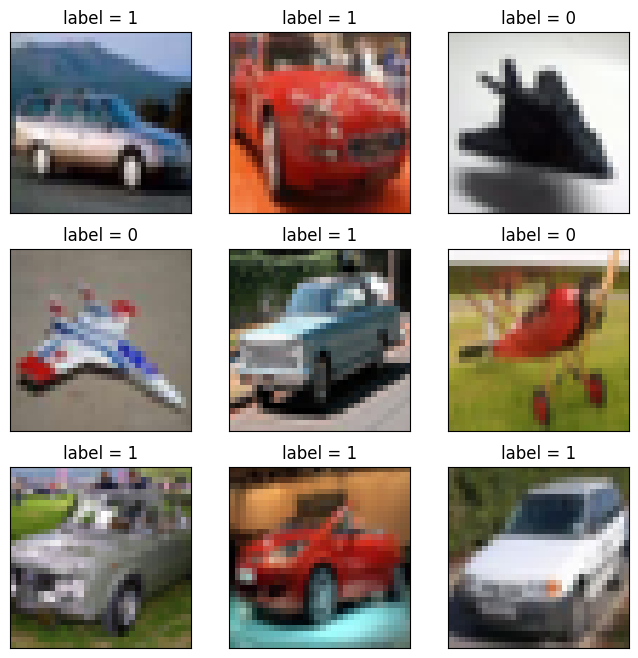

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
#查看部分样本
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 8))
for i in range(9):
    img, label = cifar2_trainset[i]
    img = img.permute(1, 2, 0)
    ax = plt.subplot(3, 3, i + 1)
    ax.imshow(img.numpy())
    ax.set_title(f"label = {label}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [15]:
import os
from torchvision.utils import save_image

# 创建文件夹结构
os.makedirs('../../data/CIFAR/cifar2/train/0_airplane', exist_ok=True)
os.makedirs('../../data/CIFAR/cifar2/train/1_automobile', exist_ok=True)
os.makedirs('../../data/CIFAR/cifar2/test/0_airplane', exist_ok=True)
os.makedirs('../../data/CIFAR/cifar2/test/1_automobile', exist_ok=True)
保存cifar2训练集的图片
for idx, (image, label) in enumerate(cifar2_trainset):
    if label == 0:  # airplane
        save_image(image, f'../../data/CIFAR/cifar2/train/0_airplane/{idx}.png')
    elif label == 1:  # automobile
        save_image(image, f'../../data/CIFAR/cifar2/train/1_automobile/{idx}.png')

# 保存cifar2测试集的图片
for idx, (image, label) in enumerate(cifar2_testset):
    if label == 0:  # airplane
        save_image(image, f'../../data/CIFAR/cifar2/test/0_airplane/{idx}.png')
    elif label == 1:  # automobile
        save_image(image, f'../../data/CIFAR/cifar2/test/1_automobile/{idx}.png')

In [13]:
'''对已制作好的图片文件夹制作数据集'''
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

trans_img = transforms.Compose([
    transforms.ToTensor()
])
train_set = datasets.ImageFolder(root='../../data/CIFAR/cifar2/train/', transform=trans_img)
val_set = datasets.ImageFolder(root='../../data/CIFAR/cifar2/test/', transform=trans_img)
print(train_set.class_to_idx)
print(type(train_set))
# Pytorch的图片默认顺序是 Batch,Channel,Width,Height
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
iterator = iter(train_loader)
batch_images, batch_labels = next(iterator)
print(batch_images.shape, batch_labels.shape)

{'0_airplane': 0, '1_automobile': 1}
<class 'torchvision.datasets.folder.ImageFolder'>
torch.Size([64, 3, 32, 32]) torch.Size([64])


# 定义模型
- 继承`nn.Module`基类，构造自定义的模型  
- `nn.Sequential`
- `nn.ModuleList`
- `nn.ModuleDict`

In [2]:
import torch.nn as nn

'''测试全局最大池化，把原始输入32*32压缩成1*1'''
pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
input = torch.randn(10, 8, 32, 32)
output = pool(input)
output.size()

torch.Size([10, 8, 1, 1])

In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.dropout = nn.Dropout2d(0.1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


model = Net()
print(model)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (dropout): Dropout2d(p=0.1, inplace=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [14]:
from torchkeras import summary

summary(model, input_data=batch_images)

--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
Conv2d-1                            [-1, 32, 30, 30]                  896
MaxPool2d-2                         [-1, 32, 15, 15]                    0
Conv2d-3                            [-1, 64, 11, 11]               51,264
MaxPool2d-4                           [-1, 64, 5, 5]                    0
Dropout2d-5                           [-1, 64, 5, 5]                    0
AdaptiveAvgPool2d-6                   [-1, 64, 1, 1]                    0
Flatten-7                                   [-1, 64]                    0
Linear-8                                    [-1, 32]                2,080
ReLU-9                                      [-1, 32]                    0
Linear-10                                    [-1, 1]                   33
Total params: 54,273
Trainable params: 54,273
Non-trainable params: 0
-----------------------------------------

'--------------------------------------------------------------------------\nLayer (type)                            Output Shape              Param #\n==========================================================================\nConv2d-1                            [-1, 32, 30, 30]                  896\nMaxPool2d-2                         [-1, 32, 15, 15]                    0\nConv2d-3                            [-1, 64, 11, 11]               51,264\nMaxPool2d-4                           [-1, 64, 5, 5]                    0\nDropout2d-5                           [-1, 64, 5, 5]                    0\nAdaptiveAvgPool2d-6                   [-1, 64, 1, 1]                    0\nFlatten-7                                   [-1, 64]                    0\nLinear-8                                    [-1, 32]                2,080\nReLU-9                                      [-1, 32]                    0\nLinear-10                                    [-1, 1]                   33\n======================

# 训练模型
- Keras风格的函数形式的训练循环

In [9]:
import os, sys, time
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from copy import deepcopy


def printlog(info):
    nowtime = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print("\n" + "==========" * 8 + f"{nowtime}")
    print(str(info) + "\n")


class StepRunner:
    def __init__(self, net, loss_fn, stage="train", optimizer=None, metrics_dict=None):
        self.net = net
        self.loss_fn = loss_fn
        self.stage = stage
        self.metrics_dict = metrics_dict
        self.optimizer = optimizer

    def step(self, features, labels):
        pred = self.net(features).squeeze()
        loss = self.loss_fn(pred, labels.float())
        if self.optimizer is not None and self.stage == "train":
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()
        step_metrics = {self.stage + "_" + name: metric_fn(pred, labels).item() for name, metric_fn in
                        self.metrics_dict.items()}
        return loss.item(), step_metrics

    def train_step(self, features, labels):
        self.net.train()  #训练模式下dropout层才发生作用
        return self.step(features, labels)

    @torch.no_grad()
    def eval_step(self, features, labels):
        self.net.eval()  #预测模式下dropout层不发生作用
        return self.step(features, labels)

    def __call__(self, features, labels):
        if self.stage == "train":
            return self.train_step(features, labels)
        else:
            return self.eval_step(features, labels)


class EpochRunner:
    def __init__(self, step_runner: StepRunner):
        self.step_runner = step_runner
        self.stage = step_runner.stage

    def __call__(self, dataloader: DataLoader):
        total_loss, step = 0, 0
        loop = tqdm(enumerate(dataloader), total=len(dataloader), file=sys.stdout)
        # epoch_log = {}  # 初始化 epoch_log 变量
        for idx, batch in loop:
            loss, step_metrics = self.step_runner(*batch)
            step_log = dict({self.stage + "_loss": loss}, **step_metrics)
            total_loss += loss
            step += 1
            if idx != len(dataloader) - 1:
                loop.set_postfix(**step_log)
            else:
                epoch_loss = total_loss / step
                epoch_metrics = {self.stage + "_" + name: metric_fn.compute().item() for name, metric_fn in
                                 self.step_runner.metrics_dict.items()}
                epoch_log = dict({self.stage + "_loss": epoch_loss}, **epoch_metrics)
                # epoch_log = {self.stage + "_loss": epoch_loss, **epoch_metrics}  # 优化后的合并字典方法
                loop.set_postfix(**epoch_log)

                for name, metric_fn in self.step_runner.metrics_dict.items():
                    metric_fn.reset()
        return epoch_log


def train_model(net, loss_fn, optimizer, metrics_dict, train_loader, val_loader=None, epochs=10,
                ckpt_path='checkpoint.pt', patience=5, monitor='val_loss', mode='min'):
    history = {}
    for epoch in range(1, epochs + 1):
        printlog(f"Epoch {epoch}/{epochs}")

        # 1，train -------------------------------------------------  
        train_step_runner = StepRunner(net, loss_fn, "train", optimizer, deepcopy(metrics_dict))
        train_epoch_runner = EpochRunner(train_step_runner)
        train_metrics = train_epoch_runner(train_loader)

        for name, metric_fn in train_metrics.items():
            history[name].append(metric_fn.compute().item())

        # 2，validate -------------------------------------------------
        if val_loader:
            val_step_runner = StepRunner(net, loss_fn, "val", None, deepcopy(metrics_dict))
            val_epoch_runner = EpochRunner(val_step_runner)

            with torch.no_grad():
                val_metrics = val_epoch_runner(val_loader)

            val_metrics["epoch"] = epoch

            for name, metric in val_metrics.items():
                history[name] = history.get(name, []) + [metric]

        # 3，early-stopping -------------------------------------------------  
        arr_scores = history[monitor]
        best_score_idx = np.argmax(arr_scores) if mode == "max" else np.argmin(arr_scores)
        if best_score_idx == len(arr_scores) - 1:
            torch.save(net.state_dict(), ckpt_path)
            print("<<<<<< reach best {0} : {1} >>>>>>".format(monitor, arr_scores[best_score_idx]), file=sys.stderr)
        if len(arr_scores) - best_score_idx > patience:
            print("<<<<<< {} without improvement in {} epoch, early stopping >>>>>>".format(monitor, patience),
                  file=sys.stderr)
            break
        net.load_state_dict(torch.load(ckpt_path))
    return pd.DataFrame(history)

In [11]:
import torchmetrics
from torchkeras.metrics import Accuracy

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
metrics_dict = {'acc': Accuracy()}
df_history = train_model(model, criterion, optimizer, metrics_dict, train_loader, val_loader, epochs=10,
                         patience=3, monitor='val_acc', mode='max')


================================================================================2025-02-25 14:31:01
Epoch 1/10

100%|██████████| 157/157 [00:08<00:00, 19.46it/s, train_acc=0.706, train_loss=0.566]


KeyError: 'train_loss'

In [1]:
from torchkeras.metrics import Accuracy 

metrics_dict = {"acc": Accuracy()} # Accuracy for binary-classification task.
metrics_dict.items()

dict_items([('acc', Accuracy())])

In [ ]:
step_metrics = {self.stage + "_" + name: metric_fn(pred, labels).item() for name, metric_fn in
                        self.metrics_dict.items()}

In [2]:
my_dict = {'a': 1, 'b': 2, 'c': 3}
for k, v in my_dict.items():
    print(k, v)

a 1
b 2
c 3


In [5]:
logits = torch.rand(4)
targets = torch.tensor([0., 1., 1., 0.])
(torch.sigmoid(logits) >= 0.5) == (targets > 0.5)

tensor([False,  True,  True, False])

In [6]:
(torch.sigmoid(logits) >= 0.5).int()

tensor([1, 1, 1, 1], dtype=torch.int32)